# channel_no_conc Workflow

推荐入口 notebook：选择一个主配置 JSON，运行该 config 声明的全部模板，保存结果；然后从其中一个模板结果继续做单 case 钻取。


In [1]:
from pathlib import Path
import json
import sys
from IPython.display import display


def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "examples" / "neuron_compare" / "channel_no_conc" / "workflows" / "workflow_api.py").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


REPO_ROOT = find_repo_root()
CHANNEL_NO_CONC_ROOT = REPO_ROOT / "examples" / "neuron_compare" / "channel_no_conc"
WORKFLOWS_ROOT = CHANNEL_NO_CONC_ROOT / "workflows"
if str(WORKFLOWS_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKFLOWS_ROOT))

import workflow_api
import brainstate
brainstate.environ.set(precision=64)


## Parameters

| 参数 | 含义 | 常见取值 |
|---|---|---|
| `config_path` | 主配置 JSON 路径；本 notebook 会跑完它声明的全部模板。因为 config/template JSON 不能写注释，所以参数解释放在这里。 | `CHANNEL_NO_CONC_ROOT / "configs" / "ma24_pc" / "hcn1_ma24_pc.json"` |
| `out_dir` | config 级输出父目录。 | `None` 使用默认目录；或手动指定路径 |
| `plot_cases` | 是否生成每个模板目录下的图产物，包括 per-case 对比图和模板级 summary 图。 | `True` / `False` |


In [2]:
config_path = CHANNEL_NO_CONC_ROOT / "configs" / "ri21_sc" / "cav2p1_ri21_sc.json" 
out_dir = None 
plot_cases = True  

## Input Preview


In [3]:
inputs = workflow_api.load_config_workflow_inputs(config_path)
print("config_path:", inputs["config_path"])
print("config_name:", inputs["config_name"])
print("mod_dir:", inputs["mod_dir"])
print("template_names:", inputs["template_names"])
print("n_templates:", inputs["n_templates"])
print("default_out_dir:", inputs["default_out_dir"])


config_path: /home/swl/braincell-ion_dyn/examples/neuron_compare/channel_no_conc/configs/ri21_sc/cav2p1_ri21_sc.json
config_name: cav2p1_ri21_sc
mod_dir: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/SC/channel
template_names: ('vinit_celsius', 'dc', 'ac')
n_templates: 3
default_out_dir: /home/swl/braincell-ion_dyn/examples/neuron_compare/channel_no_conc/results/config_runs/cav2p1_ri21_sc


## Run Workflow


In [4]:
run_info = workflow_api.run_notebook_config_workflow(
    config_path=config_path,
    out_dir=out_dir,
    plot=plot_cases,
    expand_only=False,
    raise_on_failure=False,
)
print(run_info)


--No graphics will be displayed.


{'status': 0, 'config_path': PosixPath('/home/swl/braincell-ion_dyn/examples/neuron_compare/channel_no_conc/configs/ri21_sc/cav2p1_ri21_sc.json'), 'config_name': 'cav2p1_ri21_sc', 'out_dir': PosixPath('/home/swl/braincell-ion_dyn/examples/neuron_compare/channel_no_conc/results/config_runs/cav2p1_ri21_sc'), 'manifest_path': PosixPath('/home/swl/braincell-ion_dyn/examples/neuron_compare/channel_no_conc/results/config_runs/cav2p1_ri21_sc/config_manifest.json'), 'config_runs_path': PosixPath('/home/swl/braincell-ion_dyn/examples/neuron_compare/channel_no_conc/results/config_runs/cav2p1_ri21_sc/config_runs.csv'), 'observable_summary_path': PosixPath('/home/swl/braincell-ion_dyn/examples/neuron_compare/channel_no_conc/results/config_runs/cav2p1_ri21_sc/observable_summary.csv'), 'observable_summary_json_path': PosixPath('/home/swl/braincell-ion_dyn/examples/neuron_compare/channel_no_conc/results/config_runs/cav2p1_ri21_sc/observable_summary.json'), 'failures_path': PosixPath('/home/swl/brainc

## Raw Output Overview

config 运行完成后，raw 结果会按 `config -> template -> case` 三层组织。

每个 template 子目录内至少有：

- `normalized_config.json`
- `expanded_cases.json`
- `case_results/<case_id>.json`
- `case_metrics.csv`
- `aggregate.json`
- `plots/`
  - `<case_id>.png`: 该 case 的所有观测变量对比图
  - `summary_mae.png`
  - `summary_rmse.png`
  - `summary_max_abs.png`
  - `summary_rel_mae_pct.png`
  - `observable_metric_boxplots.png`

config 根目录内至少有：

- `config_manifest.json`
- `config_runs.csv`
- `observable_summary.csv`
- `observable_summary.json`
- `failures.csv`
- `all_templates_observable_summary.png`
- `boxplot_by_template.png`
- `boxplot_by_observable_family.png`

### `run_info` 顶层字段

| 路径 | 含义 |
|---|---|
| `run_info["status"]` | config 级运行状态，`0` 表示至少有模板成功产出结果 |
| `run_info["config_name"]` | 当前 config 名称 |
| `run_info["config_path"]` | 当前 config 的绝对路径 |
| `run_info["out_dir"]` | 当前 config 的输出父目录 |
| `run_info["manifest_path"]` | config 级 manifest JSON 路径 |
| `run_info["config_runs_path"]` | config 级模板运行汇总 CSV 路径 |
| `run_info["observable_summary_path"]` | config 级 observable 汇总 CSV 路径 |
| `run_info["observable_summary_json_path"]` | config 级 observable 汇总 JSON 路径 |
| `run_info["failures_path"]` | config 级失败汇总 CSV 路径 |
| `run_info["n_templates"]` | 这个 config 一共跑了多少个模板 |
| `run_info["n_total_cases"]` | 所有模板展开后的 case 总数 |
| `run_info["n_success_cases"]` | 所有模板成功 case 总数 |
| `run_info["n_failed_cases"]` | 所有模板失败 case 总数 |
| `run_info["status_counts"]` | 模板级状态计数字典 |
| `run_info["template_runs"]` | 模板级运行记录列表，是后续选模板的主入口 |
| `run_info["observables"]` | config 级 observable 汇总记录列表 |
| `run_info["failures"]` | config 级失败记录列表；如果没有失败则为空列表 |

### `run_info["status_counts"]` 子键

| 路径 | 含义 |
|---|---|
| `run_info["status_counts"]["ok"]` | 完全成功的模板数 |
| `run_info["status_counts"]["partial"]` | 部分 case 失败但模板仍产出结果的模板数 |
| `run_info["status_counts"]["failed"]` | 模板级整体失败、没有成功结果的模板数 |

### `run_info["template_runs"]` 每行字段

| 字段 | 含义 |
|---|---|
| `run_id` | 该模板 run 的唯一标识，通常是 `config__template` |
| `config_name` | 所属 config 名称 |
| `config_path` | 所属 config 的绝对路径 |
| `template_name` | 模板名，用它来选一个模板继续分析 |
| `template_path` | 模板文件绝对路径 |
| `mod_dir` | 当前模板对应的 mod 目录 |
| `out_dir` | 该模板自己的输出目录 |
| `batch_status` | 该模板状态：`ok / partial / failed` |
| `n_total_cases` | 该模板展开的 case 数 |
| `n_success_cases` | 该模板成功 case 数 |
| `n_failed_cases` | 该模板失败 case 数 |
| `worst_observable` | 该模板里误差最坏的 observable 名 |
| `worst_max_abs_max` | 该模板里最大的 `max_abs` |
| `error_message` | 模板级失败或 partial 的摘要信息；完全成功时通常为空字符串 |

### `run_info["observables"]` 每行字段

| 字段 | 含义 |
|---|---|
| `run_id` | 来自哪个模板 run |
| `config_name` | 所属 config 名称 |
| `config_path` | 所属 config 路径 |
| `template_name` | 所属模板名 |
| `template_path` | 所属模板路径 |
| `mod_dir` | 当前模板对应的 mod 目录 |
| `batch_status` | 该模板的状态 |
| `observable` | observable 名，例如 `voltage`、`current.ix`、`gates.h` |
| `n_cases` | 参与该 observable 汇总的成功 case 数 |
| `mae_mean` | 该 observable 的平均 MAE |
| `rmse_mean` | 该 observable 的平均 RMSE |
| `max_abs_max` | 该 observable 的最大绝对误差 |
| `rel_mae_pct_mean` | 该 observable 的平均相对 MAE 百分比 |

### `run_info["failures"]` 每行字段

| 字段 | 含义 |
|---|---|
| `run_id` | 来自哪个模板 run |
| `config_name` | 所属 config 名称 |
| `template_name` | 所属模板名 |
| `config_path` | 所属 config 路径 |
| `template_path` | 所属模板路径 |
| `out_dir` | 对应模板输出目录 |
| `batch_status` | 失败类型，通常是 `partial` 或 `failed` |
| `n_failed_cases` | 失败 case 数；如果模板级整体失败且没展开成功，可能为空 |
| `error_message` | 对应失败摘要信息 |

### 进入下一层的方式

- 先从 `run_info["template_runs"]` 选一个 `template_name`
- 再取该行的 `out_dir` 作为 `template_out_dir`
- 用 `workflow_api.load_run_artifacts(template_out_dir)` 读 template 级 raw 数据
- 用 `workflow_api.build_summary_tables(template_out_dir)` 读 template 级表格
- 再从 `case_id` 进入 `workflow_api.load_case_result(template_out_dir, case_id)`


In [5]:
import pandas as pd

template_runs_df = pd.DataFrame(run_info["template_runs"])
display(template_runs_df)
print("n_templates:", run_info["n_templates"])
print("n_total_cases:", run_info["n_total_cases"])
print("n_success_cases:", run_info["n_success_cases"])
print("n_failed_cases:", run_info["n_failed_cases"])
print("status_counts:", run_info["status_counts"])


,run_id,config_name,template_name,config_path,template_path,mod_dir,out_dir,error_message,batch_status,n_total_cases,n_success_cases,n_failed_cases,worst_observable,worst_max_abs_max
0,cav2p1_ri21_sc__vinit_celsius,cav2p1_ri21_sc,vinit_celsius,/home/swl/braincell-ion_dyn/examples/neuron_co...,/home/swl/braincell-ion_dyn/examples/neuron_co...,/home/swl/braincell-ion_dyn/examples/neuron_co...,/home/swl/braincell-ion_dyn/examples/neuron_co...,,ok,3,3,0,voltage,0.000284
1,cav2p1_ri21_sc__dc,cav2p1_ri21_sc,dc,/home/swl/braincell-ion_dyn/examples/neuron_co...,/home/swl/braincell-ion_dyn/examples/neuron_co...,/home/swl/braincell-ion_dyn/examples/neuron_co...,/home/swl/braincell-ion_dyn/examples/neuron_co...,,ok,4,4,0,voltage,0.626951
2,cav2p1_ri21_sc__ac,cav2p1_ri21_sc,ac,/home/swl/braincell-ion_dyn/examples/neuron_co...,/home/swl/braincell-ion_dyn/examples/neuron_co...,/home/swl/braincell-ion_dyn/examples/neuron_co...,/home/swl/braincell-ion_dyn/examples/neuron_co...,,ok,3,3,0,voltage,0.000080


n_templates: 3
n_total_cases: 10
n_success_cases: 10
n_failed_cases: 0
status_counts: {'ok': 3, 'partial': 0, 'failed': 0}


## Optional: Inspect One Template


In [6]:
selected_template_name = str(template_runs_df.iloc[0]["template_name"])  # 可改成你想查看的模板名
print("selected_template_name:", selected_template_name)
template_run = next(
    row for row in run_info["template_runs"]
    if str(row["template_name"]) == selected_template_name
)
template_out_dir = Path(str(template_run["out_dir"])).expanduser().resolve()
artifacts = workflow_api.load_run_artifacts(template_out_dir)
tables = workflow_api.build_summary_tables(template_out_dir)
display(tables["by_observable_df"])
display(tables["failed_df"])


selected_template_name: vinit_celsius


,observable,n_rows,n_cases,mae_mean,rmse_mean,max_abs_max,rel_mae_pct_mean
0,voltage,3,3,3.897659e-05,4.737817e-05,2.838777e-04,0.000079
1,gates.m,3,3,3.784356e-07,4.737168e-07,3.030355e-06,0.000424
2,current.ix,3,3,1.309023e-08,1.387696e-08,7.143662e-08,0.014697


,case_id,group_id,status,stimulus_kind,temperature_celsius,v_init_mV,observable,n_samples,mae,rmse,...,morphology.length_um,morphology.radius_um,simulation.dt_ms,simulation.duration_ms,simulation.temperature_celsius,simulation.v_init_mV,stimulus.amp_nA,stimulus.delay_ms,stimulus.dur_ms,stimulus.kind


## Optional: Plot Template-Level Summary


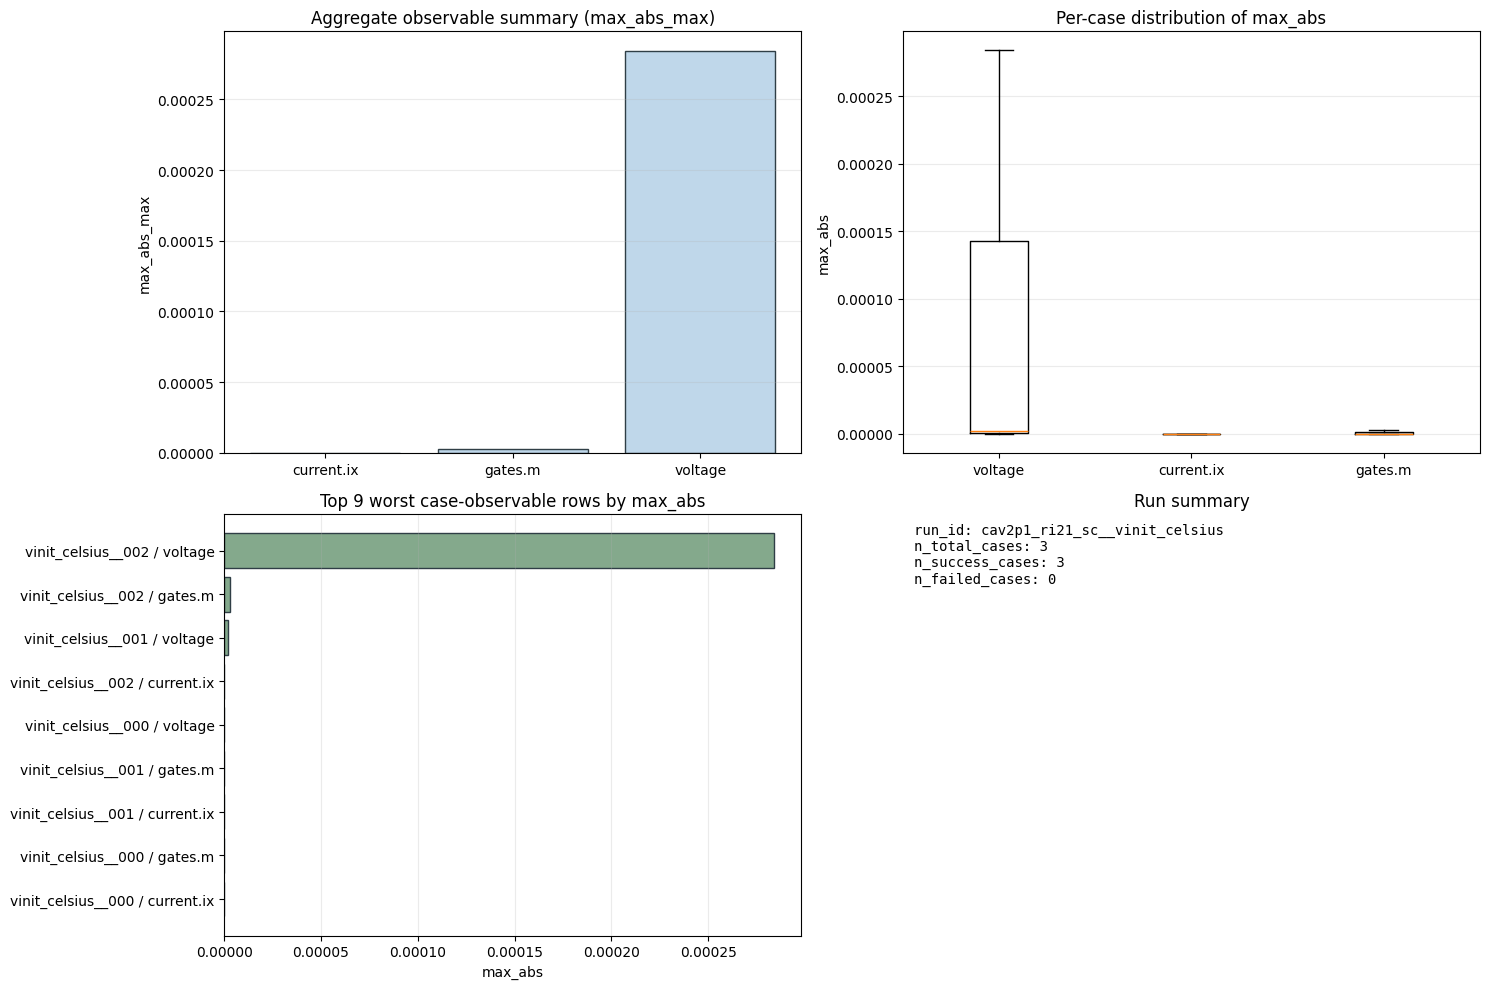

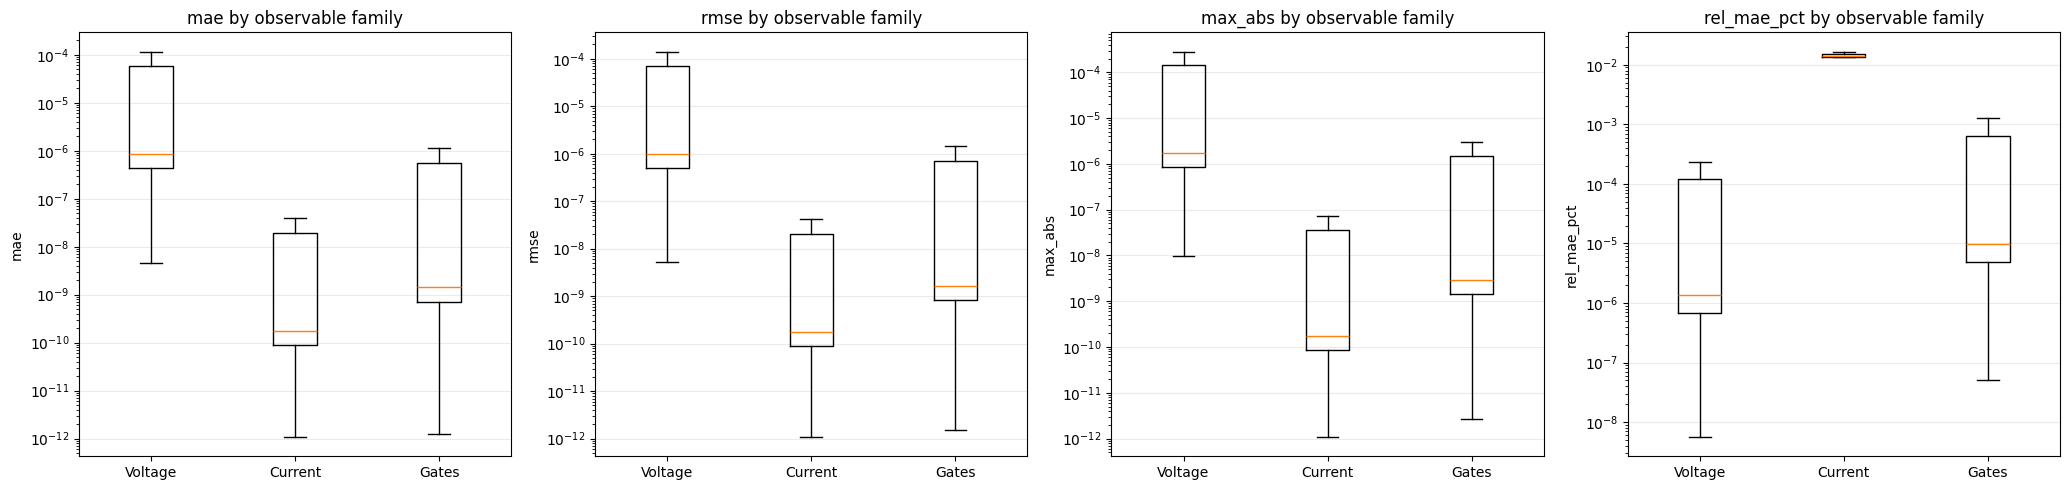

In [7]:
summary_fig, summary_axes = workflow_api.plot_sweep_summary(tables, metric="max_abs")
family_fig, family_axes = workflow_api.plot_observable_metric_boxplots(tables)


## Optional: Inspect One Case


selected_case_id: vinit_celsius__000


{'current': {'ix': {'mae': 1.0842379061480953e-12,
   'max_abs': 1.0842656903993037e-12,
   'rel_mae_pct': 0.013873248918692287,
   'rmse': 1.0842379062597107e-12}},
 'gates': {'m': {'mae': 1.2809383670951691e-12,
   'max_abs': 2.745287070587965e-12,
   'rel_mae_pct': 5.160878941548673e-08,
   'rmse': 1.5066610762408591e-12}},
 'ion_state': {'ci_mM': {'mae': 0.0,
   'max_abs': 0.0,
   'rel_mae_pct': 0.0,
   'rmse': 0.0},
  'co_mM': {'mae': 0.0, 'max_abs': 0.0, 'rel_mae_pct': 0.0, 'rmse': 0.0},
  'eca_mV': {'mae': 1.4210854715202004e-14,
   'max_abs': 1.4210854715202004e-14,
   'rel_mae_pct': 1.1817227591836644e-14,
   'rmse': 1.4210854715202004e-14}},
 'voltage': {'mae': 4.500436617149716e-09,
  'max_abs': 9.502329589849978e-09,
  'rel_mae_pct': 5.6255485220118115e-09,
  'rmse': 5.25697739583569e-09}}

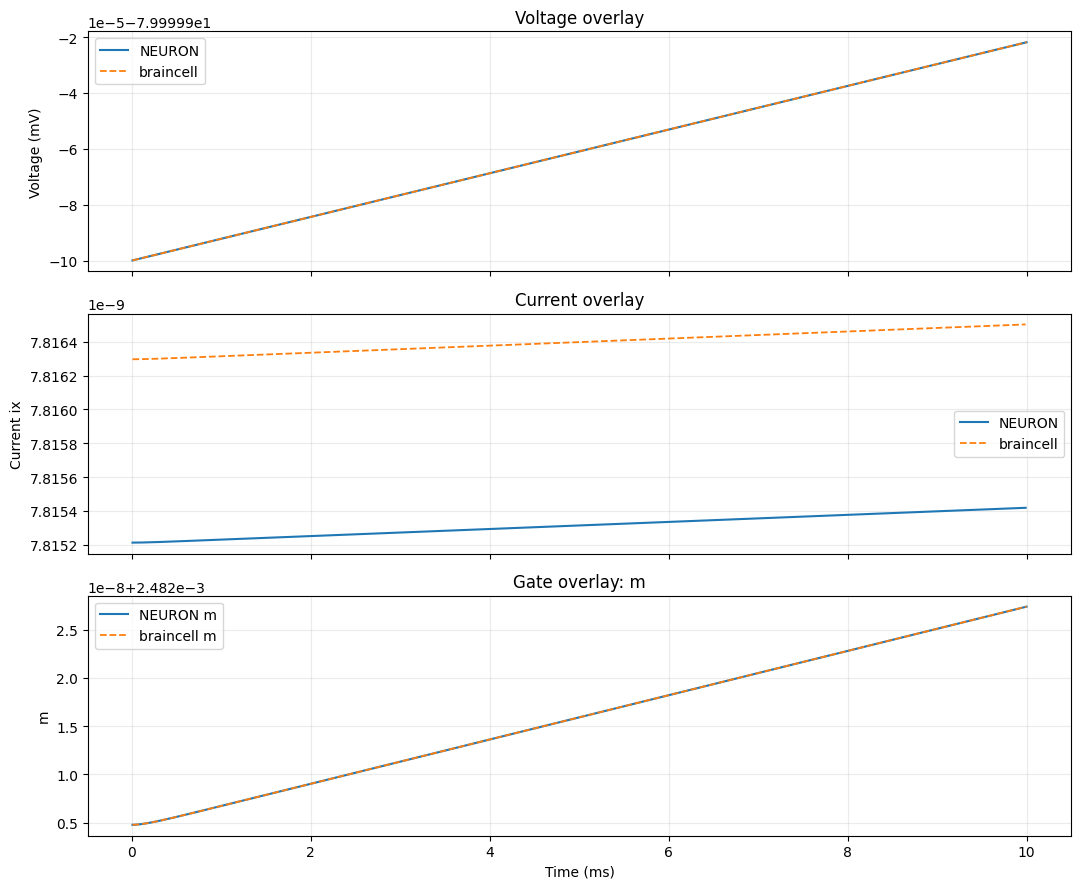

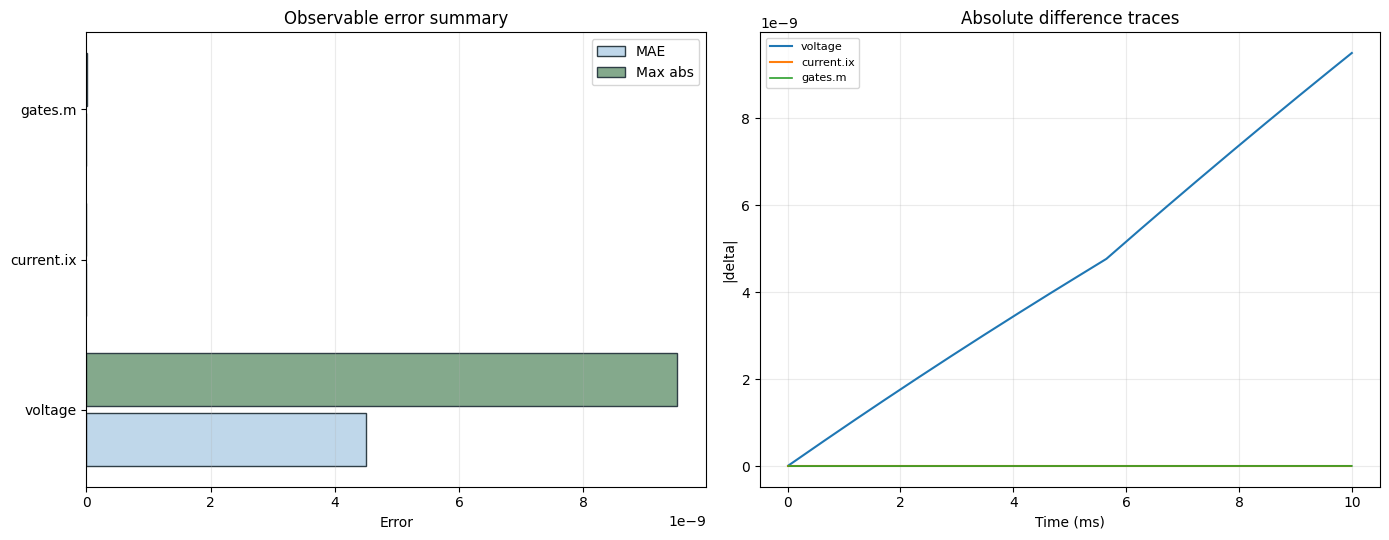

In [8]:
selected_case_id = str(tables["ok_df"].iloc[0]["case_id"]) 
print("selected_case_id:", selected_case_id)
case_result = workflow_api.load_case_result(template_out_dir, selected_case_id)
display(case_result["metrics"])
overlay_fig, overlay_axes = workflow_api.plot_case_overlay(case_result, include_gates=True)
error_fig, error_axes = workflow_api.plot_case_error_summary(case_result)
